# 02 — Classical A/B Analysis (Stage 1, Task 1)

Single-test deep dive on three illustrative tests from `v_exploratory_clean`, chosen to exercise the classical toolkit end to end: pairwise two-proportion tests, chi-square across arms, Wilson CIs per arm, and a Newcombe CI on the best-vs-worst difference for the clean-winner case.

**Framing note (applies to every test in this notebook, and to Stage 1 generally):** these are multivariate horse-race tests — every arm is a novel candidate headline/image package, none is a pre-existing "control." Upworthy ran these purely to pick a winner among alternatives, not to test a treatment against a status quo. So results below are described as *"package A outperforms package B"*, never *"treatment beats control."* This is a deliberate framing choice reflecting how the experiments were actually designed, not a data limitation.

**View used:** `v_exploratory_clean`.

**Tests analyzed:**
1. **High-traffic exemplar** — `533a186ba0c400d7d2000006` (4 arms, "undershirt renaming" piece). Near the top of the impressions-per-arm distribution. This test has 4 arms total; the deep-dive below focuses specifically on the best-vs-worst pair to illustrate a clean, high-confidence result — it is not a "top 2 by CTR" comparison, and the other 2 arms are not analyzed here (that full 4-arm or 6-arm treatment is what the multi-arm exemplar below is for).
2. **Low-traffic exemplar** — `54e4cf5f373139001a900000` (4 arms, bullying-comic piece). Near the bottom of the impressions-per-arm distribution, to show what wide/overlapping Wilson CIs look like even when raw CTRs differ visibly — sets up the power/MDE discussion in the next notebook.
3. **Multi-arm exemplar** — `5356b47475478fe7b1000004` (6 arms, "Whole Foods / food gentrification" piece), at the archive's median arm count, to give the chi-square-across-arms step and the BH correction real multiple-comparisons structure (15 pairwise comparisons) rather than a toy case.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from clickworthy import classical as cl
from clickworthy import data_access as da

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.dpi"] = 100

ALPHA = 0.05

TEST_IDS = {
    "high_traffic": "533a186ba0c400d7d2000006",
    "low_traffic": "54e4cf5f373139001a900000",
    "multi_arm": "5356b47475478fe7b1000004",
}

con = da.connect()
tests = {name: da.load_test(con, tid) for name, tid in TEST_IDS.items()}
con.close()

for name, df in tests.items():
    print(f"{name}: {TEST_IDS[name]} -- {len(df)} arms, "
          f"impressions/arm {df['impressions'].min():,}-{df['impressions'].max():,}")

high_traffic: 533a186ba0c400d7d2000006 -- 4 arms, impressions/arm 7,967-8,175
low_traffic: 54e4cf5f373139001a900000 -- 4 arms, impressions/arm 1,510-1,575
multi_arm: 5356b47475478fe7b1000004 -- 6 arms, impressions/arm 2,206-2,292


## 1. High-traffic exemplar — `533a186ba0c400d7d2000006`

**Piece:** a comedy segment about renaming an awkwardly-named article of clothing (undershirts). 4 arms total, ~8,000-8,175 impressions per arm — near the top of the archive's impressions-per-arm distribution.

First, look at the raw rates and Wilson CIs for all 4 arms (exploratory, before picking a comparison pair).

In [2]:
arm_summary_ht = cl.arm_summary(tests["high_traffic"])
arm_summary_ht

,headline,impressions,clicks,ctr,wilson_low,wilson_high
0,He's Funny But He's Right - Why A Seemingly Innocent Piece Of Clothing Needs...,8175,264,0.032294,0.028676,0.036351
1,My Favorite Comedian Takes A Stab At The Piece Of Clothing We've All Thought...,7967,249,0.031254,0.027653,0.035306
2,"Opening SNL Monologue Attacks Popular Piece Of Clothing, Claiming It's Name ...",8090,214,0.026452,0.023174,0.030180
3,"Why Our Undershirts Needs A Name Change, Immediately",8073,138,0.017094,0.014488,0.020160


**Observation:** with ~8,000 impressions per arm, click counts land in the low hundreds (138-264), which is enough for the Wilson intervals to be visibly narrow (roughly +/-1 percentage point) relative to the CTR differences between arms. This is exactly the traffic regime where "the winner is clean" is a believable claim rather than noise.

**This test has 4 arms total.** The deep-dive below deliberately restricts to the best-performing arm ("He's Funny But He's Right...", 3.23% CTR) vs. the worst-performing arm ("Why Our Undershirts Needs A Name Change...", 1.71% CTR) to illustrate a clean, high-confidence result. This is *not* a "top 2 by CTR" comparison — the middle two arms are not analyzed here. A full 4-arm (or larger) treatment, with chi-square across all arms and BH-adjusted pairwise comparisons, is what the multi-arm exemplar (Section 3) is for.

In [3]:
best = arm_summary_ht.iloc[0]
worst = arm_summary_ht.iloc[-1]

print("Best:  ", best["headline"])
print(f"       {int(best['clicks'])}/{int(best['impressions'])} = {best['ctr']:.4f}")
print("Worst: ", worst["headline"])
print(f"       {int(worst['clicks'])}/{int(worst['impressions'])} = {worst['ctr']:.4f}")

z_stat, p_raw = cl.two_proportion_test(
    best["clicks"], best["impressions"], worst["clicks"], worst["impressions"]
)
diff_low, diff_high = cl.newcombe_diff_ci(
    best["clicks"], best["impressions"], worst["clicks"], worst["impressions"], ALPHA
)
abs_lift, rel_lift = cl.lift(
    best["clicks"], best["impressions"], worst["clicks"], worst["impressions"]
)

print()
print("Method: two-proportion score (Wald-type) z-test for the point estimate/p-value;")
print("        Newcombe (score-based) CI for the difference p_best - p_worst.")
print("Assumptions: two independent binomial samples (impressions fixed by random assignment,")
print("             clicks ~ Binomial(impressions, p)); no continuity correction needed at this n.")
print()
print(f"z = {z_stat:.3f}, p = {p_raw:.2e}")
print(f"Absolute lift (best - worst): {abs_lift:+.4f} ({abs_lift*100:+.2f} pp)")
print(f"Relative lift: {rel_lift:+.1%}")
print(f"Newcombe 95% CI on absolute lift: [{diff_low:.4f}, {diff_high:.4f}]  "
      f"([{diff_low*100:+.2f} pp, {diff_high*100:+.2f} pp])")

Best:   He's Funny But He's Right - Why A Seemingly Innocent Piece Of Clothing Needs A New Name
       264/8175 = 0.0323
Worst:  Why Our Undershirts Needs A Name Change, Immediately
       138/8073 = 0.0171

Method: two-proportion score (Wald-type) z-test for the point estimate/p-value;
        Newcombe (score-based) CI for the difference p_best - p_worst.
Assumptions: two independent binomial samples (impressions fixed by random assignment,
             clicks ~ Binomial(impressions, p)); no continuity correction needed at this n.

z = 6.236, p = 4.49e-10
Absolute lift (best - worst): +0.0152 (+1.52 pp)
Relative lift: +88.9%
Newcombe 95% CI on absolute lift: [0.0105, 0.0200]  ([+1.05 pp, +2.00 pp])


**Interpretation:** the best arm outperforms the worst arm by 1.52 percentage points (an 89% relative lift), and the Newcombe 95% CI on that difference, [1.05 pp, 2.00 pp], excludes zero by a wide margin (p = 4.5e-10). At this traffic level the two package's underlying click rates are clearly separated — a textbook case of a "clean, unambiguous winner" that a classical A/B test is well-suited to detect.

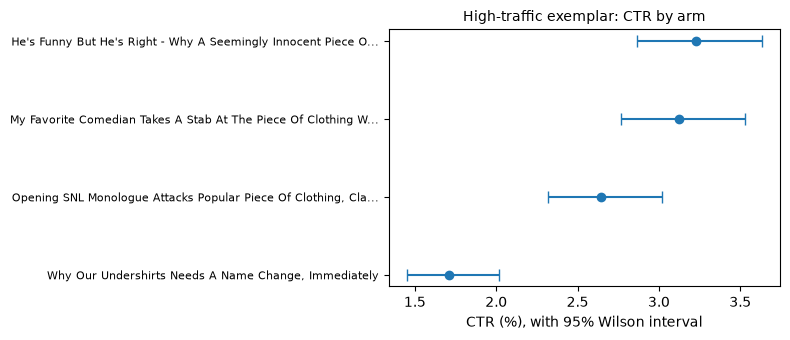

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.5))
summary = arm_summary_ht
y = np.arange(len(summary))[::-1]
ax.errorbar(
    summary["ctr"] * 100, y,
    xerr=[
        (summary["ctr"] - summary["wilson_low"]) * 100,
        (summary["wilson_high"] - summary["ctr"]) * 100,
    ],
    fmt="o", capsize=4, color="tab:blue",
)
labels = [h[:60] + ("..." if len(h) > 60 else "") for h in summary["headline"]]
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("CTR (%), with 95% Wilson interval")
ax.set_title("High-traffic exemplar: CTR by arm", fontsize=10)
ax.set_ylabel("")

fig.tight_layout()
plt.show()

**Interpretation:** the plot makes the same point visually — the best and worst arms' Wilson intervals don't overlap, while the two middle arms sit in between with intervals that do overlap their neighbors. This is the shape of evidence we'd want before calling a winner in production: non-overlapping intervals at the extremes, not just a difference in point estimates.

## 2. Low-traffic exemplar — `54e4cf5f373139001a900000`

**Piece:** a bullying-themed comic, 4 arms, ~1,510-1,575 impressions per arm — near the bottom of the impressions-per-arm distribution (click counts confirmed >= 10 per arm during test selection, so intervals are wide but not degenerate).

In [5]:
arm_summary_lt = cl.arm_summary(tests["low_traffic"])
arm_summary_lt

,headline,impressions,clicks,ctr,wilson_low,wilson_high
0,"The bully punches him in the face. Later, he follows the bully home, and tha...",1575,84,0.053333,0.043283,0.065557
1,A comic about bullying with an ending I did not see coming *at all.*,1510,46,0.030464,0.022916,0.040394
2,"All he wanted was to get revenge on his bully. But when he tried, he discove...",1518,42,0.027668,0.020534,0.037187
3,"They start as enemies, but when they become friends at the end, it's so many...",1541,19,0.012330,0.007907,0.019177


**Observation:** raw CTRs range from 1.23% to 5.33% — a visually large spread — but click counts per arm are only 19-84. That's the low-count regime CLAUDE.md flags: normal approximations break down here, which is exactly why Wilson (not Wald) intervals are the standard for this project.

In [6]:
pairwise_lt = cl.pairwise_tests(tests["low_traffic"], ALPHA)
pairwise_lt[
    ["headline_a", "headline_b", "ctr_a", "ctr_b", "abs_lift", "rel_lift",
     "z_stat", "p_raw", "p_bh", "newcombe_diff_low", "newcombe_diff_high"]
].sort_values("p_raw")

,headline_a,headline_b,ctr_a,ctr_b,abs_lift,rel_lift,z_stat,p_raw,p_bh,newcombe_diff_low,newcombe_diff_high
4,"The bully punches him in the face. Later, he follows the bully home, and tha...","They start as enemies, but when they become friends at the end, it's so many...",0.053333,0.012330,0.041004,3.325614,6.399930,1.554478e-10,9.326866e-10,0.028843,0.054002
3,"The bully punches him in the face. Later, he follows the bully home, and tha...","All he wanted was to get revenge on his bully. But when he tried, he discove...",0.053333,0.027668,0.025665,0.927619,3.609101,3.072599e-04,9.217798e-04,0.011823,0.039818
2,A comic about bullying with an ending I did not see coming *at all.*,"They start as enemies, but when they become friends at the end, it's so many...",0.030464,0.012330,0.018134,1.470756,3.467607,5.251153e-04,1.050231e-03,0.007943,0.029004
0,A comic about bullying with an ending I did not see coming *at all.*,"The bully punches him in the face. Later, he follows the bully home, and tha...",0.030464,0.053333,-0.022870,-0.428808,-3.160073,1.577298e-03,2.365947e-03,-0.037236,-0.008741
5,"All he wanted was to get revenge on his bully. But when he tried, he discove...","They start as enemies, but when they become friends at the end, it's so many...",0.027668,0.012330,0.015338,1.244019,3.033565,2.416830e-03,2.900196e-03,0.005450,0.025834
1,A comic about bullying with an ending I did not see coming *at all.*,"All he wanted was to get revenge on his bully. But when he tried, he discove...",0.030464,0.027668,0.002796,0.101041,0.457814,6.470859e-01,6.470859e-01,-0.009352,0.015023


**Method:** all `4 choose 2 = 6` pairwise two-proportion score tests within this test's arms, Benjamini-Hochberg-adjusted across those 6 comparisons (CLAUDE.md's within-test multiple-comparisons convention), with a Newcombe CI on each pairwise difference.

**Interpretation:** despite the ~4x spread in raw CTR between the best and worst arms, only the single most extreme pairwise comparison survives BH correction at alpha=0.05; the rest do not. Several Newcombe CIs on the pairwise differences span zero. This is the intended illustration for this exemplar: at ~1,500 impressions/arm and single-digit-to-low-double-digit click counts, apparent gaps in raw CTR are largely consistent with noise once uncertainty is quantified properly — the wide/overlapping-CI case that motivates the power/MDE discussion in Stage 1 Task 2.

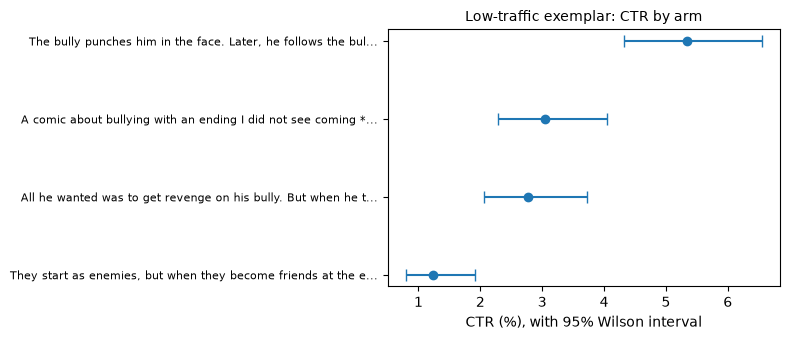

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.5))
summary = arm_summary_lt
y = np.arange(len(summary))[::-1]
ax.errorbar(
    summary["ctr"] * 100, y,
    xerr=[
        (summary["ctr"] - summary["wilson_low"]) * 100,
        (summary["wilson_high"] - summary["ctr"]) * 100,
    ],
    fmt="o", capsize=4, color="tab:blue",
)
labels = [h[:60] + ("..." if len(h) > 60 else "") for h in summary["headline"]]
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("CTR (%), with 95% Wilson interval")
ax.set_title("Low-traffic exemplar: CTR by arm", fontsize=10)
ax.set_ylabel("")

fig.tight_layout()
plt.show()

**Interpretation:** visually, three of the four intervals overlap substantially; only the best arm's interval clears the worst arm's. Compare the interval widths here (several points wide) against the high-traffic exemplar's (roughly 1 point wide) — same estimator (Wilson), wildly different precision, purely a function of sample size per arm.

## 3. Multi-arm exemplar — `5356b47475478fe7b1000004`

**Piece:** a "food gentrification" / Whole Foods commentary piece, 6 arms (at the archive's median arm count), ~2,206-2,292 impressions per arm.

In [8]:
arm_summary_ma = cl.arm_summary(tests["multi_arm"])
arm_summary_ma

,headline,impressions,clicks,ctr,wilson_low,wilson_high
0,Hipsters At Whole Foods May Be Hurting A Lot More People They Realize,2215,104,0.046953,0.038900,0.056574
1,The Cost Of Being A Trendy Eater Hurts A Lot More People Than The Whole Food...,2292,60,0.026178,0.020392,0.033550
2,"Great, Now the Hipsters Have Taken Over Our Grocery Stores, Too. It's Not Pr...",2206,48,0.021759,0.016451,0.028730
3,Organic Foods Are All The Rage Now. And It's Kind Of A Bad Thing.,2236,38,0.016995,0.012407,0.023239
4,Eating Healthy Is Now The Cool Thing To Do. Which Is Why Most People Can No...,2241,33,0.014726,0.010505,0.020607
5,"If You Wanna Be Cool, You Gotta Eat Kale. And, Oh Yeah, Have A Lot Of Money.",2226,31,0.013926,0.009828,0.019699


**Observation:** CTRs range from 1.39% to 4.70% across the 6 arms — a real spread, not a toy case, and enough arms (`6 choose 2 = 15` pairs) to make the chi-square-across-arms step and BH correction meaningfully different from a single pairwise test.

In [9]:
chi2_stat, chi2_p, dof = cl.chi_square_across_arms(tests["multi_arm"])
print("Method: chi-square test of k independent proportions (statsmodels proportions_chisquare),")
print("        testing the null that all 6 arms share one true CTR.")
print(f"chi2 = {chi2_stat:.2f}, dof = {dof}, p = {chi2_p:.2e}")

Method: chi-square test of k independent proportions (statsmodels proportions_chisquare),
        testing the null that all 6 arms share one true CTR.
chi2 = 74.92, dof = 5, p = 9.66e-15


**Interpretation:** the chi-square test rejects the null of a single shared CTR across all 6 arms overwhelmingly (p ~ 1e-14). That tells us *some* arm(s) differ, but not *which* pairs — that's what the pairwise comparisons below are for.

In [10]:
pairwise_ma = cl.pairwise_tests(tests["multi_arm"], ALPHA)
pairwise_ma_display = pairwise_ma[
    ["headline_a", "headline_b", "ctr_a", "ctr_b", "abs_lift", "rel_lift",
     "z_stat", "p_raw", "p_bh", "newcombe_diff_low", "newcombe_diff_high"]
].sort_values("p_raw")
pairwise_ma_display

,headline_a,headline_b,ctr_a,ctr_b,abs_lift,rel_lift,z_stat,p_raw,p_bh,newcombe_diff_low,newcombe_diff_high
11,"If You Wanna Be Cool, You Gotta Eat Kale. And, Oh Yeah, Have A Lot Of Money.",Hipsters At Whole Foods May Be Hurting A Lot More People They Realize,0.013926,0.046953,-0.033026,-0.703396,-6.409093,1.463879e-10,2.195819e-09,-0.043484,-0.023118
13,Eating Healthy Is Now The Cool Thing To Do. Which Is Why Most People Can No...,Hipsters At Whole Foods May Be Hurting A Lot More People They Realize,0.014726,0.046953,-0.032227,-0.686374,-6.230172,4.659247e-10,3.494435e-09,-0.042733,-0.022255
8,Organic Foods Are All The Rage Now. And It's Kind Of A Bad Thing.,Hipsters At Whole Foods May Be Hurting A Lot More People They Realize,0.016995,0.046953,-0.029958,-0.638047,-5.685683,1.302910e-08,6.514552e-08,-0.040617,-0.019768
14,"Great, Now the Hipsters Have Taken Over Our Grocery Stores, Too. It's Not Pr...",Hipsters At Whole Foods May Be Hurting A Lot More People They Realize,0.021759,0.046953,-0.025194,-0.536579,-4.596305,4.300497e-06,1.612687e-05,-0.036182,-0.014543
4,The Cost Of Being A Trendy Eater Hurts A Lot More People Than The Whole Food...,Hipsters At Whole Foods May Be Hurting A Lot More People They Realize,0.026178,0.046953,-0.020775,-0.442459,-3.723105,1.967876e-04,5.903627e-04,-0.032002,-0.009857
1,The Cost Of Being A Trendy Eater Hurts A Lot More People Than The Whole Food...,"If You Wanna Be Cool, You Gotta Eat Kale. And, Oh Yeah, Have A Lot Of Money.",0.026178,0.013926,0.012252,0.879750,2.930322,3.386112e-03,8.465281e-03,0.004078,0.020686
2,The Cost Of Being A Trendy Eater Hurts A Lot More People Than The Whole Food...,Eating Healthy Is Now The Cool Thing To Do. Which Is Why Most People Can No...,0.026178,0.014726,0.011452,0.777725,2.719182,6.544355e-03,1.402362e-02,0.003202,0.019947
0,The Cost Of Being A Trendy Eater Hurts A Lot More People Than The Whole Food...,Organic Foods Are All The Rage Now. And It's Kind Of A Bad Thing.,0.026178,0.016995,0.009183,0.540369,2.122931,3.375959e-02,6.329924e-02,0.000670,0.017866
10,"If You Wanna Be Cool, You Gotta Eat Kale. And, Oh Yeah, Have A Lot Of Money.","Great, Now the Hipsters Have Taken Over Our Grocery Stores, Too. It's Not Pr...",0.013926,0.021759,-0.007833,-0.359969,-1.970196,4.881586e-02,8.135977e-02,-0.015919,0.000010
12,Eating Healthy Is Now The Cool Thing To Do. Which Is Why Most People Can No...,"Great, Now the Hipsters Have Taken Over Our Grocery Stores, Too. It's Not Pr...",0.014726,0.021759,-0.007033,-0.323237,-1.753401,7.953312e-02,1.192997e-01,-0.015182,0.000890


In [11]:
n_sig_raw = (pairwise_ma["p_raw"] < ALPHA).sum()
n_sig_bh = (pairwise_ma["p_bh"] < ALPHA).sum()
print(f"Of {len(pairwise_ma)} pairwise comparisons: {n_sig_raw} significant at raw alpha=0.05, "
      f"{n_sig_bh} significant after BH adjustment.")

Of 15 pairwise comparisons: 9 significant at raw alpha=0.05, 7 significant after BH adjustment.


**Method:** all 15 pairwise two-proportion score tests among the 6 arms, BH-adjusted jointly across all 15 (not per-arm) — CLAUDE.md's convention of adjusting across all comparisons made within one test.

**Interpretation:** raw and BH-adjusted significance counts diverge here, which is the point of running both: testing every pair invites false positives from multiple looks, and BH correction is the guardrail. The arm "Hipsters At Whole Foods May Be Hurting..." (4.70% CTR) drives most of the surviving comparisons — it's decisively ahead of every other arm — while several of the remaining pairs among the lower-CTR arms are not distinguishable even before correction. This is the archive-representative multi-arm case: one clear standout, several arms that are statistically indistinguishable from each other.

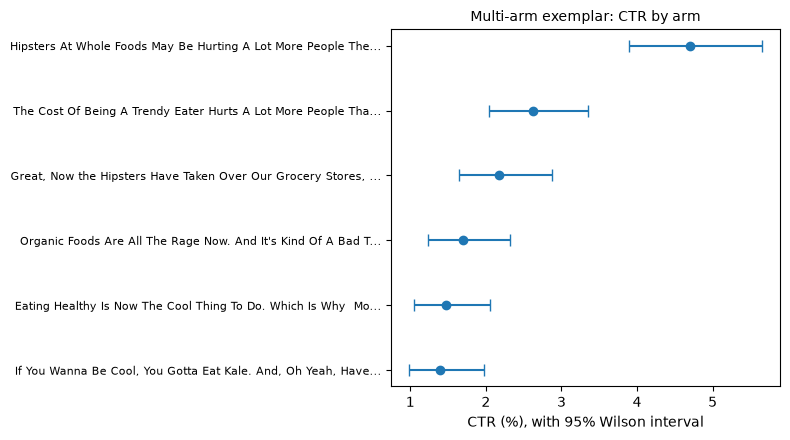

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
summary = arm_summary_ma
y = np.arange(len(summary))[::-1]
ax.errorbar(
    summary["ctr"] * 100, y,
    xerr=[
        (summary["ctr"] - summary["wilson_low"]) * 100,
        (summary["wilson_high"] - summary["ctr"]) * 100,
    ],
    fmt="o", capsize=4, color="tab:blue",
)
labels = [h[:60] + ("..." if len(h) > 60 else "") for h in summary["headline"]]
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("CTR (%), with 95% Wilson interval")
ax.set_title("Multi-arm exemplar: CTR by arm", fontsize=10)
ax.set_ylabel("")

fig.tight_layout()
plt.show()

**Interpretation:** the top arm's interval is visibly separated from the bottom four; the bottom four/five overlap each other extensively. This matches the pairwise-test pattern above — one standout, a cluster of arms that can't be reliably told apart from this sample size alone.

## Summary

- **High-traffic exemplar (4 arms):** best-vs-worst comparison (not a top-2 comparison) shows a clean, high-confidence winner — 1.52 pp absolute lift (89% relative), Newcombe 95% CI [1.05 pp, 2.00 pp], p = 4.5e-10. This test's other 2 arms were not analyzed here.
- **Low-traffic exemplar (4 arms):** raw CTRs span ~4x, but only the single most extreme pairwise gap survives BH correction; most pairwise Newcombe CIs include zero — a real-world case of "looks different, isn't distinguishable yet."
- **Multi-arm exemplar (6 arms):** chi-square across all arms rejects a shared-CTR null decisively; of 15 pairwise comparisons, raw and BH-adjusted significance counts diverge, with one arm standing out clearly above a cluster of statistically indistinguishable others.
- All CIs use the Wilson (single proportion) / Newcombe (difference) conventions from CLAUDE.md; all multi-comparison adjustment uses Benjamini-Hochberg across each test's own pairwise comparisons.
- Framing throughout: "package A outperforms package B" — none of these tests had a true control arm.

Next (Stage 1 Task 2, same notebook): power and MDE at typical baseline CTR and impressions, quantifying how underpowered typical archive tests were (checkpoint with Phil before starting).